# Traffic Sign Classification using KNN + HOG Features
### GTSRB (German Traffic Sign Recognition Benchmark)

This notebook implements traffic sign classification using:
- **Feature Extraction:** Histogram of Oriented Gradients (HOG)
- **Classifier:** K-Nearest Neighbors (KNN)
- **Evaluation:** Accuracy, Precision, Recall, F1-score, Confusion Matrix, Visualizations

---
**Expected dataset structure** (GTSRB - Kaggle "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign" version):
```
dataset/
├── Train/
│   ├── 0/   (images for class 0)
│   ├── 1/   (images for class 1)
│   ├── ...
│   └── 42/  (images for class 42)
├── Test/
│   └── *.png
└── labels.csv
```
Download from: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
and update `DATASET_PATH` below to point to the extracted folder.


In [138]:
# ============================================================
# 1. Imports
# ============================================================
import os
import numpy as np
import pandas as pd
import cv2
from skimage.feature import hog
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Configuration

Update `DATASET_PATH` to the folder where you extracted the GTSRB dataset.
`IMG_SIZE` controls the size images are resized to before HOG extraction — 32x32 or 64x64 are common choices for GTSRB.

In [139]:
"""
Check for duplicate filenames between the Train and Test image folders.
 
This is useful before training, since if the same filename appears in both
Train and Test, it could mean the same image was accidentally included in
both sets (data leakage), which would make your test accuracy look
artificially high / not trustworthy.
 
"""
 
import os
 
# ============================================================
# Configuration
# ============================================================
TRAIN_DIR = "./dataset/TRAIN"     # can contain subfolders (e.g. Train/0, Train/1, ...)
TEST_DIR = "./dataset/TEST"       # test images folder
 
# If True: automatically deletes any duplicate-named files.
# If False: only prints the list of duplicate filenames (with full paths)
# so you can review and delete them yourself.
DELETE_DUPLICATES = True
 
# Which folder to delete duplicates FROM, if DELETE_DUPLICATES is True.
# "train" = delete the duplicate files from the Train folder (keep Test)
# "test"  = delete the duplicate files from the Test folder (keep Train)
DELETE_FROM = "train"
 
 
def collect_filenames(root_dir):
    """
    Walks through root_dir (including subfolders) and returns a dict
    mapping filename -> full path. If a filename appears more than once
    within the same folder (e.g. across multiple class subfolders),
    only the last path found is kept for that filename.
    """
    filename_to_path = {}
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            full_path = os.path.join(dirpath, fname)
            filename_to_path[fname] = full_path
    return filename_to_path
 
 
def find_duplicate_filenames(train_dir, test_dir):
    train_files = collect_filenames(train_dir)
    test_files = collect_filenames(test_dir)
 
    train_names = set(train_files.keys())
    test_names = set(test_files.keys())
 
    duplicate_names = train_names & test_names  # names that appear in both
 
    return duplicate_names, train_files, test_files
 
 
def main():
    print(f"Scanning Train folder: {TRAIN_DIR}")
    print(f"Scanning Test folder:  {TEST_DIR}\n")
 
    duplicate_names, train_files, test_files = find_duplicate_filenames(TRAIN_DIR, TEST_DIR)
 
    if not duplicate_names:
        print("No duplicate filenames found between Train and Test. You're good to go!")
        return
 
    print(f"Found {len(duplicate_names)} duplicate filename(s) between Train and Test:\n")
    for name in sorted(duplicate_names):
        print(f"  - {name}")
        print(f"      Train: {train_files[name]}")
        print(f"      Test:  {test_files[name]}")
 
    if DELETE_DUPLICATES:
        target_files = train_files if DELETE_FROM == "train" else test_files
        target_label = "Train" if DELETE_FROM == "train" else "Test"
 
        print(f"\nDELETE_DUPLICATES is True — deleting duplicate files from the {target_label} folder...")
        deleted_count = 0
        for name in duplicate_names:
            path_to_delete = target_files[name]
            try:
                os.remove(path_to_delete)
                deleted_count += 1
                print(f"  Deleted: {path_to_delete}")
            except OSError as e:
                print(f"  Failed to delete {path_to_delete}: {e}")
        print(f"\nDone. Deleted {deleted_count} file(s) from the {target_label} folder.")
    else:
        print("\nDELETE_DUPLICATES is False — no files were deleted.")
        print("Review the list above, then either:")
        print("  (a) set DELETE_DUPLICATES = True (and check DELETE_FROM) and re-run this script, or")
        print("  (b) delete the listed files yourself.")
 
 
if __name__ == "__main__":
    main()
 

Scanning Train folder: ./dataset/TRAIN
Scanning Test folder:  ./dataset/TEST

No duplicate filenames found between Train and Test. You're good to go!


# for checking if they is near-duplicate traffic sign images (dont run)

In [140]:
"""
Detect near-duplicate images between the Train and Test folders using
PERCEPTUAL HASHING (based on image content, not filename).
 
Why this matters: even if you already removed files with identical
filenames, the same physical sign could have been photographed multiple
times and saved under DIFFERENT filenames in Train vs Test. If those
near-identical images end up split across Train and Test, your model can
"memorize" them, leading to unrealistically high (e.g. 100%) test accuracy.
 
This script compares every test image's content against every train
image's content and flags pairs that are visually near-identical.
 
Usage:
    1. pip install imagehash pillow tqdm --break-system-packages
    2. Update TRAIN_DIR and TEST_DIR below.
    3. Run the script. It will print any near-duplicate pairs found.
"""
 
import os
from PIL import Image
import imagehash
from tqdm import tqdm
 
# ============================================================
# Configuration
# ============================================================
TRAIN_DIR = "./dataset/Train"
TEST_DIR = "./dataset/TEST/Inputs - Original"   # the folder containing Blue Signs / Red Signs / Yellow Signs
 
# Hash similarity threshold: 0 = identical images.
# Small values (0-5) catch near-duplicates (same photo, minor edits/compression).
# Increase cautiously if you want to catch more loosely similar images,
# but too high a threshold will start flagging genuinely different signs.
HAMMING_DISTANCE_THRESHOLD = 5
 
 
def collect_image_paths(root_dir):
    """Recursively collect all image file paths under root_dir."""
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp")
    paths = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.lower().endswith(valid_ext):
                paths.append(os.path.join(dirpath, fname))
    return paths
 
 
def compute_hashes(image_paths, label):
    """Computes a perceptual hash for each image. Skips unreadable files."""
    hashes = {}
    for path in tqdm(image_paths, desc=f"Hashing {label} images"):
        try:
            with Image.open(path) as img:
                h = imagehash.phash(img)
                hashes[path] = h
        except Exception as e:
            print(f"  Could not read {path}: {e}")
    return hashes
 
 
def find_near_duplicates(train_hashes, test_hashes, threshold):
    """
    Compares every test image hash against every train image hash.
    Returns a list of (test_path, train_path, hamming_distance) for pairs
    within the given threshold.
    """
    matches = []
    for test_path, test_hash in tqdm(test_hashes.items(), desc="Comparing Test vs Train"):
        for train_path, train_hash in train_hashes.items():
            distance = test_hash - train_hash  # Hamming distance
            if distance <= threshold:
                matches.append((test_path, train_path, distance))
    return matches
 
 
def main():
    train_paths = collect_image_paths(TRAIN_DIR)
    test_paths = collect_image_paths(TEST_DIR)
 
    print(f"Found {len(train_paths)} train images, {len(test_paths)} test images.\n")
 
    train_hashes = compute_hashes(train_paths, "train")
    test_hashes = compute_hashes(test_paths, "test")
 
    print(f"\nComparing images (threshold = {HAMMING_DISTANCE_THRESHOLD})...")
    matches = find_near_duplicates(train_hashes, test_hashes, HAMMING_DISTANCE_THRESHOLD)
 
    if not matches:
        print("\nNo near-duplicate images found between Train and Test. Your split looks clean!")
        return
 
    print(f"\nFound {len(matches)} near-duplicate pair(s):\n")
    for test_path, train_path, distance in sorted(matches, key=lambda x: x[2]):
        print(f"  Distance {distance}:")
        print(f"    Test:  {test_path}")
        print(f"    Train: {train_path}")
 
    # Also summarize which test images are affected (a test image may match
    # multiple train images, e.g. if the same sign was photographed many times)
    affected_test_images = sorted(set(m[0] for m in matches))
    print(f"\n{len(affected_test_images)} out of {len(test_paths)} test images have at least one near-duplicate in Train.")
    print("Consider removing these test images, or removing their matching Train counterparts,")
    print("before re-running your KNN evaluation, to get a trustworthy accuracy figure.")
 
 
if __name__ == "__main__":
    main()
 

Found 3910 train images, 84 test images.



Hashing test images: 100%|██████████| 84/84 [00:00<00:00, 225.82it/s]



Comparing images (threshold = 5)...


Comparing Test vs Train: 100%|██████████| 84/84 [00:01<00:00, 51.88it/s]


No near-duplicate images found between Train and Test. Your split looks clean!


# delete all the Train images that were flagged as near-duplicates (dont run)

In [141]:
"""
Automatically deletes all TRAIN images that were flagged as near-duplicates
of TEST images (based on perceptual hashing).
 
Run this AFTER running check_near_duplicates.py, or just run this script
directly — it re-computes the duplicate check itself, then deletes the
matching Train images automatically (no manual deletion needed).
 
Usage:
    1. pip install imagehash pillow tqdm --break-system-packages
    2. Update TRAIN_DIR and TEST_DIR below to match your dataset.
    3. Run this script. It will print exactly which Train files were deleted.
    4. Afterwards, RESTART YOUR NOTEBOOK KERNEL and re-run the KNN notebook
       from scratch, so it loads the updated (deduplicated) Train folder.
"""
 
import os
from PIL import Image
import imagehash
from tqdm import tqdm
 
# ============================================================
# Configuration
# ============================================================
TRAIN_DIR = "./dataset/Train"
TEST_DIR = "./dataset/TEST/Inputs - Original"
 
HAMMING_DISTANCE_THRESHOLD = 5
 
# Safety switch: set to False first to preview what WOULD be deleted,
# then set to True once you've confirmed the list looks correct.
ACTUALLY_DELETE = True
 
 
def collect_image_paths(root_dir):
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp")
    paths = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.lower().endswith(valid_ext):
                paths.append(os.path.join(dirpath, fname))
    return paths
 
 
def compute_hashes(image_paths, label):
    hashes = {}
    for path in tqdm(image_paths, desc=f"Hashing {label} images"):
        try:
            with Image.open(path) as img:
                hashes[path] = imagehash.phash(img)
        except Exception as e:
            print(f"  Could not read {path}: {e}")
    return hashes
 
 
def find_duplicate_train_paths(train_hashes, test_hashes, threshold):
    """Returns the set of TRAIN paths that matched at least one TEST image."""
    matched_train_paths = set()
    for test_path, test_hash in tqdm(test_hashes.items(), desc="Comparing Test vs Train"):
        for train_path, train_hash in train_hashes.items():
            if (test_hash - train_hash) <= threshold:
                matched_train_paths.add(train_path)
    return matched_train_paths
 
 
def main():
    train_paths = collect_image_paths(TRAIN_DIR)
    test_paths = collect_image_paths(TEST_DIR)
    print(f"Found {len(train_paths)} train images, {len(test_paths)} test images.\n")
 
    train_hashes = compute_hashes(train_paths, "train")
    test_hashes = compute_hashes(test_paths, "test")
 
    print(f"\nFinding Train images that duplicate Test images (threshold = {HAMMING_DISTANCE_THRESHOLD})...")
    duplicate_train_paths = find_duplicate_train_paths(train_hashes, test_hashes, HAMMING_DISTANCE_THRESHOLD)
 
    if not duplicate_train_paths:
        print("\nNo duplicate Train images found. Nothing to delete.")
        return
 
    print(f"\n{len(duplicate_train_paths)} Train image(s) flagged as duplicates of Test images:\n")
    for path in sorted(duplicate_train_paths):
        print(f"  {path}")
 
    # ---- Safety check: warn if any class would be left with very few (or zero) images ----
    from collections import Counter
    class_counts_before = Counter()
    class_counts_after = Counter()
    for path in train_paths:
        class_id = os.path.basename(os.path.dirname(path))
        class_counts_before[class_id] += 1
        if path not in duplicate_train_paths:
            class_counts_after[class_id] += 1
 
    print("\nClass balance check (images remaining per class after deletion):")
    problem_classes = []
    for class_id in sorted(class_counts_before, key=lambda x: int(x) if x.isdigit() else x):
        before = class_counts_before[class_id]
        after = class_counts_after.get(class_id, 0)
        flag = ""
        if after == 0:
            flag = "  <-- WARNING: would have 0 images left!"
            problem_classes.append(class_id)
        elif after < 3:
            flag = "  <-- WARNING: very few images left"
            problem_classes.append(class_id)
        print(f"  Class {class_id}: {before} -> {after}{flag}")
 
    if problem_classes:
        print(f"\n/!\\ {len(problem_classes)} class(es) would end up with 0-2 training images: {problem_classes}")
        print("Consider keeping at least one image per class instead of deleting all matches for these classes,")
        print("or manually reviewing these specific matches before proceeding.")
 
    if ACTUALLY_DELETE:
        print(f"\nACTUALLY_DELETE is True — deleting {len(duplicate_train_paths)} file(s)...")
        deleted, failed = 0, 0
        for path in duplicate_train_paths:
            try:
                os.remove(path)
                deleted += 1
            except OSError as e:
                print(f"  Failed to delete {path}: {e}")
                failed += 1
        print(f"\nDone. Deleted {deleted} file(s), failed to delete {failed} file(s).")
        print("Now RESTART your notebook kernel and re-run the KNN notebook from scratch.")
    else:
        print(f"\nACTUALLY_DELETE is False — nothing was deleted (preview mode).")
        print("Review the list above. If it looks correct, set ACTUALLY_DELETE = True and re-run this script.")
 
 
if __name__ == "__main__":
    main()
 

Found 3910 train images, 84 test images.



Hashing test images: 100%|██████████| 84/84 [00:00<00:00, 246.97it/s]



Finding Train images that duplicate Test images (threshold = 5)...


Comparing Test vs Train: 100%|██████████| 84/84 [00:01<00:00, 56.50it/s]


No duplicate Train images found. Nothing to delete.


In [142]:
# ============================================================
# 2. Configuration
# ============================================================
DATASET_PATH = "./dataset"                     # <-- change this to your dataset root
TRAIN_DIR = os.path.join(DATASET_PATH, "TRAIN")
TEST_DIR = os.path.join(DATASET_PATH, "TEST", "Inputs - Original")  # contains Blue Signs / Red Signs / Yellow Signs
LABEL_CSV = os.path.join(DATASET_PATH, "labels.csv")   # ClassId -> Name mapping (for readability only)
IMG_SIZE = (64, 64)                # resize target (width, height)
NUM_CLASSES = 58                   # update this to match your actual number of classes


## 3. Load Images

Loads training images from the `Train/<class_id>/` folder structure, and
test images using the paths listed in `Test.csv`.

In [143]:
# ============================================================
# 3. Load Images
# ============================================================
import re

def load_test_images(test_dir, img_size):
    # Initialize lists to store resized images, labels, original images, and skipped files
    images, labels, orig_images, skipped = [], [], [], []

    # Get all subdirectories (representing colors like Blue, Red, Yellow)
    color_folders = [f for f in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, f))]
    all_files = []
    
    # Collect all image file paths
    for folder in color_folders:
        folder_path = os.path.join(test_dir, folder)
        for file_name in os.listdir(folder_path):
            all_files.append((folder, file_name, os.path.join(folder_path, file_name)))

    # Process each image file
    for folder, file_name, img_path in tqdm(all_files, desc="Loading test images"):
        # Extract the true class ID from the filename
        class_id = parse_class_id_from_filename(file_name)
        if class_id is None:
            skipped.append((folder, file_name))
            continue

        # Read the image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            skipped.append((folder, file_name))
            continue

        # [CRUCIAL STEP] Save a copy of the original high-resolution image BEFORE resizing
        orig_images.append(img.copy())

        # Resize the image to the specified IMG_SIZE (e.g., 64x64) for model prediction
        img_resized = cv2.resize(img, img_size)
        images.append(img_resized)
        labels.append(class_id)

    if skipped:
        print(f"Warning: skipped {len(skipped)} file(s).")

    # Return the resized images, labels, and the original high-resolution images
    return images, labels, orig_images

# ------------------------------------------------------------
# Load training and test datasets
# Ensure you unpack 3 variables for the test set here:
# ------------------------------------------------------------
train_images, train_labels = load_training_images(TRAIN_DIR, IMG_SIZE)
test_images, test_labels, test_orig_images = load_test_images(TEST_DIR, IMG_SIZE)

Loading test images: 100%|██████████| 84/84 [00:00<00:00, 313.78it/s]


## 4. Feature Extraction — HOG (Histogram of Oriented Gradients) + HSV (Hue, Saturation, Value color space)

Images are converted to grayscale before HOG extraction, since HOG operates on
gradient/edge information rather than color.

In [144]:
# ============================================================
# 4. Feature Extraction - HOG + HSV Color Histogram
# ============================================================
def extract_hog_and_hsv_features(images, orientations=12, pixels_per_cell=(8, 8), cells_per_block=(4, 4), hsv_bins=16):
    """
    Extracts HOG shape features and HSV color histogram features from images, 
    and concatenates them into a single feature vector.
    """
    features = []
    for img in tqdm(images, desc="Extracting HOG + HSV features"):
        # --- 1. Extract HOG shape features ---
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hog_feat = hog(
            gray,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm="L2-Hys",
            feature_vector=True,
        )
        
        # --- 2. Extract HSV color features ---
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
        # Calculate the histogram for the Hue channel
        # Note: Hue range in OpenCV is 0-180
        hist_hue = cv2.calcHist([hsv], [0], None, [hsv_bins], [0, 180])
        cv2.normalize(hist_hue, hist_hue) # Normalize the histogram
        
        # Calculate the histogram for the Saturation channel
        # Note: Saturation range in OpenCV is 0-256
        hist_sat = cv2.calcHist([hsv], [1], None, [hsv_bins], [0, 256])
        cv2.normalize(hist_sat, hist_sat) # Normalize the histogram
        
        # --- 3. Concatenate all features ---
        # Flatten color histograms and concatenate with HOG features
        color_feat = np.concatenate((hist_hue.flatten(), hist_sat.flatten()))
        combined_feat = np.concatenate((hog_feat, color_feat))
        
        features.append(combined_feat)
        
    return np.array(features)

# Extract combined features for train and test sets
X_train = extract_hog_and_hsv_features(train_images)
X_test = extract_hog_and_hsv_features(test_images)
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f"Combined feature vector length: {X_train.shape[1]}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Extracting HOG + HSV features: 100%|██████████| 84/84 [00:00<00:00, 468.18it/s]

Combined feature vector length: 4832
X_train shape: (3910, 4832), X_test shape: (84, 4832)


## 5. Hold-out Validation Split

Split the training set further into train/validation so we can tune `k`
without touching the test set.

In [145]:
# ============================================================
# 5. Train / Validation Split
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)
print(f"Train: {X_tr.shape[0]} samples | Validation: {X_val.shape[0]} samples")


Train: 3128 samples | Validation: 782 samples


## 6. Hyperparameter Tuning — Choosing the Best k

KNN's accuracy is highly sensitive to the choice of `k` (number of neighbors).
This loop tests a range of k values and plots validation accuracy for each,
so we can justify the chosen k in the report.

In [146]:
# ============================================================
# 6. Hyperparameter Tuning: k
# ============================================================
k_values = [1, 3, 5, 7, 9, 11, 15]
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_tr, y_tr)
    val_pred = knn.predict(X_val)
    acc = accuracy_score(y_val, val_pred)
    val_accuracies.append(acc)
    print(f"k={k}: validation accuracy = {acc:.4f}")

best_k = k_values[int(np.argmax(val_accuracies))]
print(f"\nBest k = {best_k} (validation accuracy = {max(val_accuracies):.4f})")


k=1: validation accuracy = 0.9949
k=3: validation accuracy = 0.9514
k=5: validation accuracy = 0.9552
k=7: validation accuracy = 0.9514
k=9: validation accuracy = 0.9450
k=11: validation accuracy = 0.9399
k=15: validation accuracy = 0.9246

Best k = 1 (validation accuracy = 0.9949)


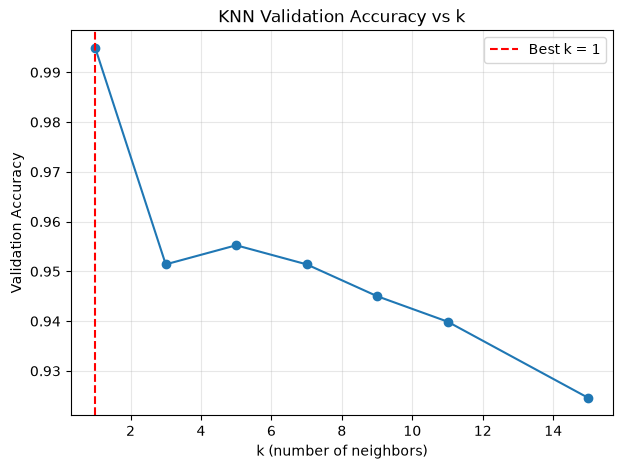

In [147]:
# Plot k vs validation accuracy
plt.figure(figsize=(7, 5))
plt.plot(k_values, val_accuracies, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k = {best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Validation Accuracy")
plt.title("KNN Validation Accuracy vs k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Train Final KNN Model

Train on the full training set (train + validation) using the best `k` found above, then evaluate on the held-out **test** set.

In [148]:
# ============================================================
# 7. Train Final Model
# ============================================================
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
final_knn.fit(X_train, y_train)

y_pred = final_knn.predict(X_test)


## 8. Evaluation Metrics

Reporting accuracy, precision, recall, and F1-score (macro-averaged across all 43 classes, since GTSRB classes are imbalanced).

In [149]:
# ============================================================
# 8. Evaluation Metrics
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Test Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, zero_division=0))


Test Accuracy:  0.8690
Precision (macro): 0.8648
Recall (macro):    0.8958
F1-score (macro):  0.8702

Full classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.67      1.00      0.80         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       0.50      1.00      0.67         1
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         1
     

## 9. Confusion Matrix

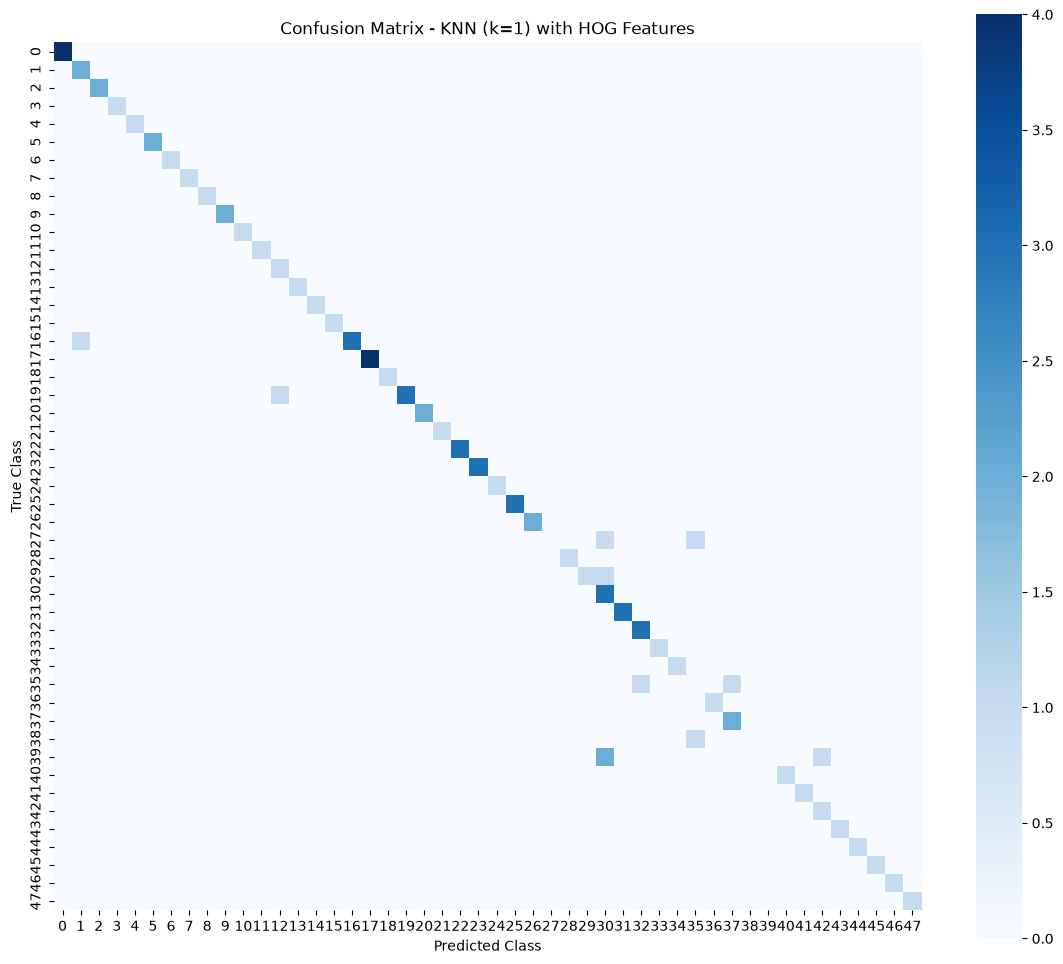

In [150]:
# ============================================================
# 9. Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=True, square=True)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix - KNN (k={best_k}) with HOG Features")
plt.show()


## 10. Sample Predictions Visualization

Displays a few test images with their true vs predicted labels, useful for
qualitative error analysis in your report.

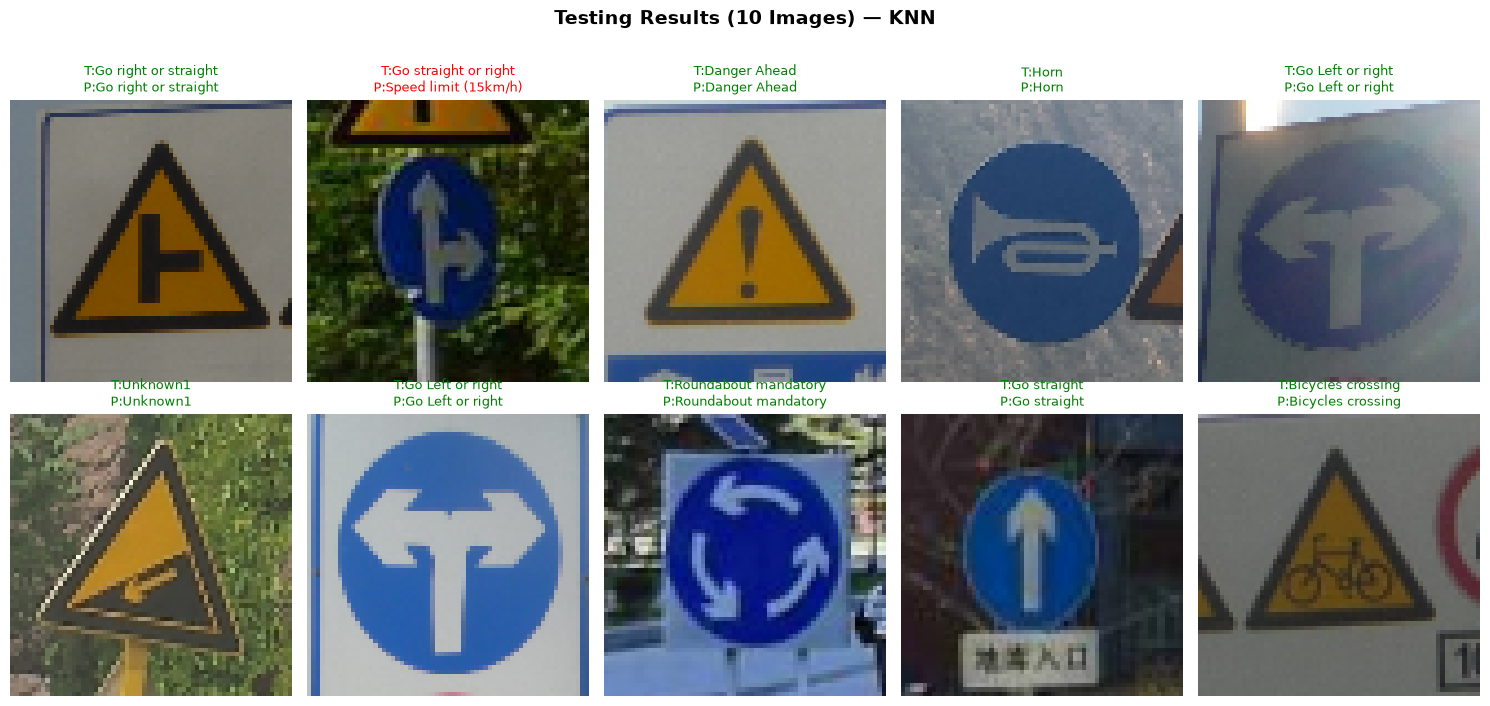

In [151]:
# ============================================================
# 10. Visualize Sample Predictions (T: / P: style, matching report format)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

NUM_SAMPLES = 10   # change to however many images you want to display
COLS = 5            # images per row

sample_indices = np.random.choice(len(test_images), min(NUM_SAMPLES, len(test_images)), replace=False)

rows = int(np.ceil(len(sample_indices) / COLS))
fig, axes = plt.subplots(rows, COLS, figsize=(3 * COLS, 3.5 * rows))
fig.suptitle(f"Testing Results ({len(sample_indices)} Images) \u2014 KNN", fontsize=14, fontweight="bold", y=1.02)

axes = np.array(axes).reshape(-1)  # flatten in case of a single row
for ax, idx in zip(axes, sample_indices):
    img_rgb = cv2.cvtColor(test_images[idx], cv2.COLOR_BGR2RGB)
    true_label = y_test[idx]
    pred_label = y_pred[idx]

    # Look up human-readable names if label.csv was loaded successfully
    true_name = class_id_to_name.get(true_label, str(true_label))
    pred_name = class_id_to_name.get(pred_label, str(pred_label))

    is_correct = (true_label == pred_label)
    color = "green" if is_correct else "red"

    ax.imshow(img_rgb)
    ax.axis("off")
    ax.set_title(f"T:{true_name}\nP:{pred_name}", color=color, fontsize=9)

# Hide any unused subplot axes (if NUM_SAMPLES isn\'t a multiple of COLS)
for ax in axes[len(sample_indices):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=200, bbox_inches="tight")
plt.show()


## 11. Export Results for All Test Images

In [152]:
# ============================================================
# 11. Export Full Results for All Test Images (High-Res 2x2 Grid)
# ============================================================
import csv
import math
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ---- 1. Export prediction results for every test image to a CSV file ----
csv_path = "all_test_results.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    # Write the header row
    writer.writerow(["Index", "True_ClassId", "True_Name", "Pred_ClassId", "Pred_Name", "Correct"])
    
    # Write the data rows
    for idx in range(len(test_images)):
        true_label = y_test[idx]
        pred_label = y_pred[idx]
        
        # Fetch human-readable class names (fallback to ID string if not found)
        true_name = class_id_to_name.get(true_label, str(true_label))
        pred_name = class_id_to_name.get(pred_label, str(pred_label))
        
        # Check if the prediction is correct
        correct = (true_label == pred_label)
        writer.writerow([idx, true_label, true_name, pred_label, pred_name, correct])

print(f"Saved full results for {len(test_images)} test images to '{csv_path}'")

# ---- 2. Split all test images into multiple 2x2 grid PNG files using ORIGINAL images ----
IMAGES_PER_FILE = 4   # Number of images per grid (2x2)
GRID_COLS = 2
GRID_ROWS = 2

n_total = len(test_images)
n_files = math.ceil(n_total / IMAGES_PER_FILE)

print(f"\nGenerating {n_files} file(s) with high-res images...")

for file_idx in range(n_files):
    # Calculate the start and end indices for the current file
    start = file_idx * IMAGES_PER_FILE
    end = min(start + IMAGES_PER_FILE, n_total)
    indices_in_this_file = list(range(start, end))

    # Create a 2x2 subplot figure
    fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(8, 8))
    axes = np.array(axes).reshape(-1) # Flatten axes array for easy iteration

    for ax, idx in zip(axes, indices_in_this_file):
        # [CRUCIAL CHANGE] Use test_orig_images (high-res) instead of test_images (downscaled 64x64)
        # Convert BGR (OpenCV format) to RGB (Matplotlib format)
        img_rgb = cv2.cvtColor(test_orig_images[idx], cv2.COLOR_BGR2RGB)
        
        true_label = y_test[idx]
        pred_label = y_pred[idx]
        true_name = class_id_to_name.get(true_label, str(true_label))
        pred_name = class_id_to_name.get(pred_label, str(pred_label))
        
        # Determine title color based on correctness
        is_correct = (true_label == pred_label)
        color = "green" if is_correct else "red"

        # Display the image. interpolation='bicubic' provides smooth edge transitions
        ax.imshow(img_rgb, interpolation='bicubic')
        ax.axis("off")
        ax.set_title(f"T:{true_name}\nP:{pred_name}", color=color, fontsize=11, fontweight="bold")

    # Hide any unused subplot slots in the last file (if images aren't a multiple of 4)
    for ax in axes[len(indices_in_this_file):]:
        ax.axis("off")

    # Set the main title for the figure
    fig.suptitle(f"Testing Results — KNN (Images {start+1}-{end} of {n_total})", fontsize=14, fontweight="bold")
    plt.tight_layout()

    # Save the figure as a high-resolution PNG (300 DPI)
    out_name = f"all_test_predictions_part{file_idx+1:02d}.png"
    plt.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.close(fig) # Close the figure to free up memory

print(f"Saved {n_files} high-res grid files (all_test_predictions_part01.png ...)")

Saved full results for 84 test images to 'all_test_results.csv'

Generating 21 file(s) with high-res images...
Saved 21 high-res grid files (all_test_predictions_part01.png ...)


## 11. Summary

| Metric | Value |
|---|---|
| Feature Extraction | HOG (12 orientations, 8x8 cells, 4x4 blocks) + HSV|
| Classifier | KNN |
| Best k | 1 |
| Test Accuracy | 86.90% |